# 🏥 Healthcare Capstone Project: Diabetes Risk Prediction
**Apex Skill Technologies — Theme 1: Healthcare**  
*Instructor: Sidmal Madhan*  

### 📋 Project Overview & Problem Statement
Diabetes mellitus is a chronic metabolic condition that leads to serious health complications if left undiagnosed. The objective of this capstone project is to build an end-to-end Machine Learning diagnostic system to predict whether a patient is diabetic based on medical diagnostic indicators.

Per the capstone guidelines, we implement and compare **4 distinct Machine Learning architectures**:
1. **M1 — Logistic Regression:** Interpretable linear classification baseline.
2. **M2 — Polynomial Logistic Regression (deg=2):** Captures non-linear health interactions.
3. **M3 — Decision Tree Classifier:** Transparent, rule-based clinical decision splits.
4. **M4 — Random Forest Classifier:** High-capacity ensemble handling noisy biomedical measurements.

### 🌟 Bonus Implementations
- **Hyperparameter Tuning:** Exhaustive `GridSearchCV` optimization.
- **Cross-Validation:** 5-fold stratified cross-validation for robust generalization estimates.
- **Interactive Web Demo:** Streamlit web application with real-time patient risk evaluation and training median fallback.

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Visualization configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", font="sans-serif")
%matplotlib inline

## 1. Load and Inspect Dataset
The dataset is the **Pima Indians Diabetes Database**, containing diagnostic measurements from 768 female patients of Pima Indian heritage aged 21 and older.

In [4]:
df = pd.read_csv('../data/dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (768, 9)


In [5]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. Exploratory Data Analysis (EDA)
We construct 5 comprehensive visualizations to analyze feature distributions, correlations, class balance, and biological anomalies.

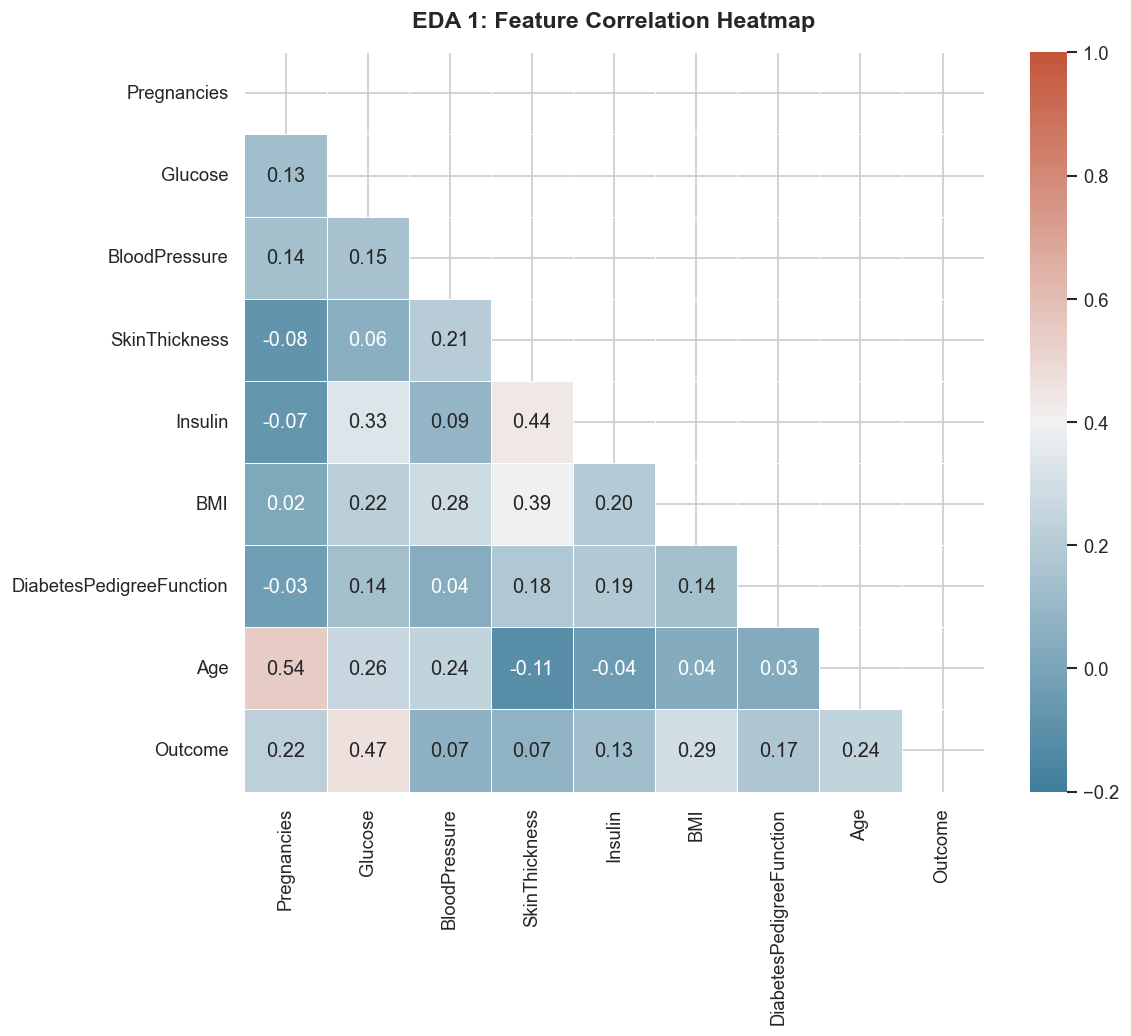

In [7]:
# EDA 1: Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=sns.diverging_palette(230, 20, as_cmap=True),
            mask=mask, vmax=1.0, vmin=-0.2, square=True, linewidths=.5)
plt.title("EDA 1: Feature Correlation Heatmap", fontsize=14, fontweight='bold', pad=15)
plt.show()

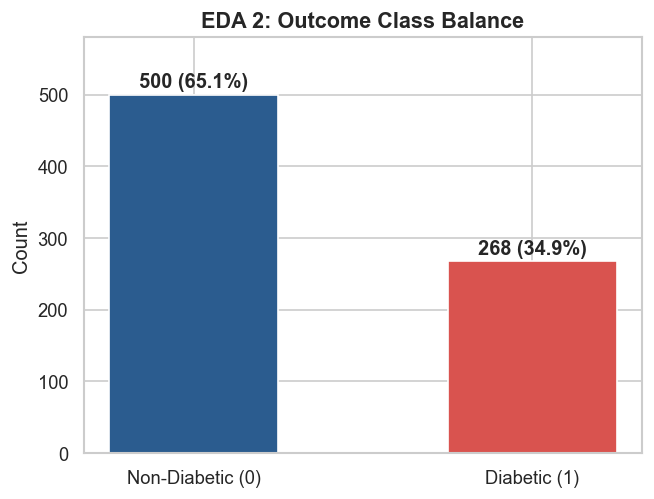

In [8]:
# EDA 2: Outcome Class Balance Bar Chart
plt.figure(figsize=(6, 4.5))
counts = df['Outcome'].value_counts()
bars = plt.bar(["Non-Diabetic (0)", "Diabetic (1)"], counts.values, color=['#2b5c8f', '#d9534f'], width=0.5)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 10, f"{yval} ({yval/len(df)*100:.1f}%)", ha='center', fontweight='bold')
plt.title("EDA 2: Outcome Class Balance", fontsize=13, fontweight='bold')
plt.ylabel("Count")
plt.ylim(0, 580)
plt.show()

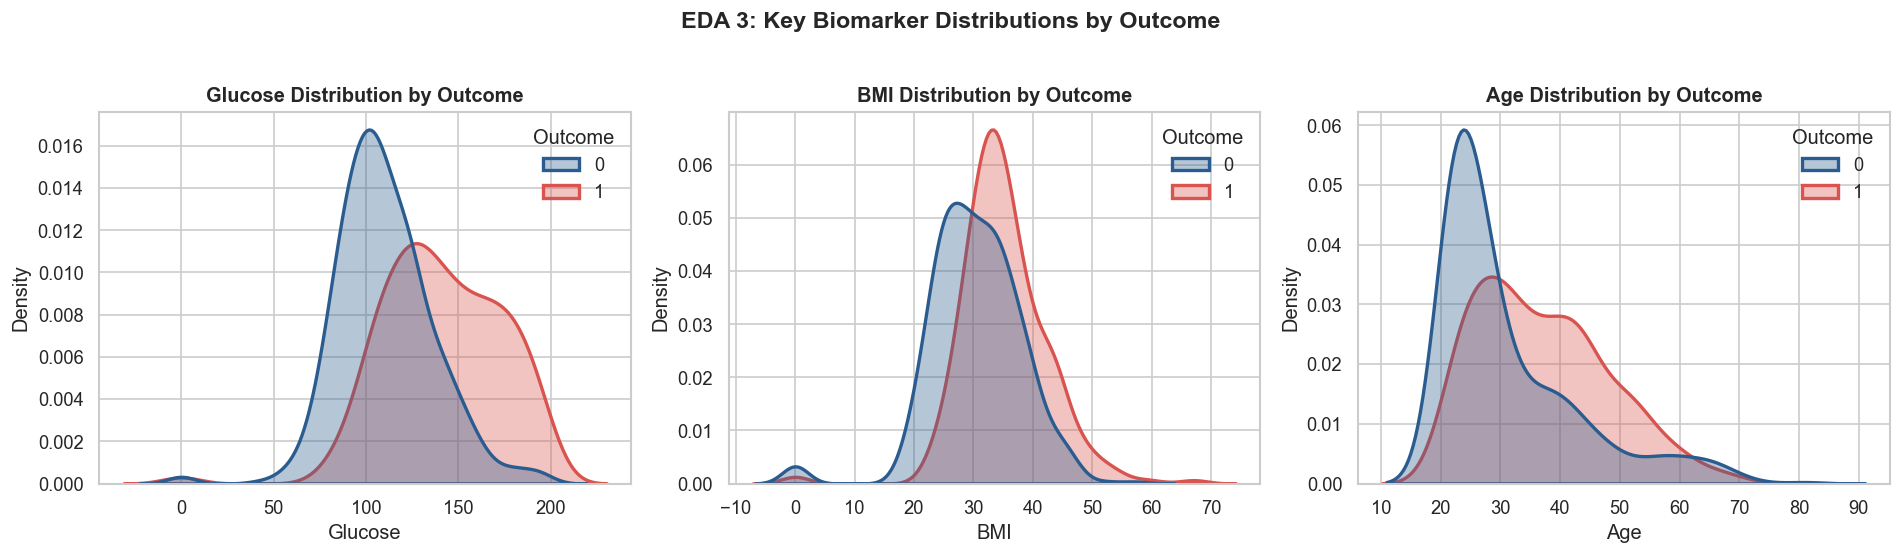

In [9]:
# EDA 3: Feature Distributions by Outcome
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, feat in enumerate(['Glucose', 'BMI', 'Age']):
    sns.kdeplot(data=df, x=feat, hue='Outcome', common_norm=False, fill=True, alpha=0.35,
                palette=['#2b5c8f', '#d9534f'], ax=axes[i], linewidth=2)
    axes[i].set_title(f"{feat} Distribution by Outcome", fontweight='bold')
plt.suptitle("EDA 3: Key Biomarker Distributions by Outcome", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

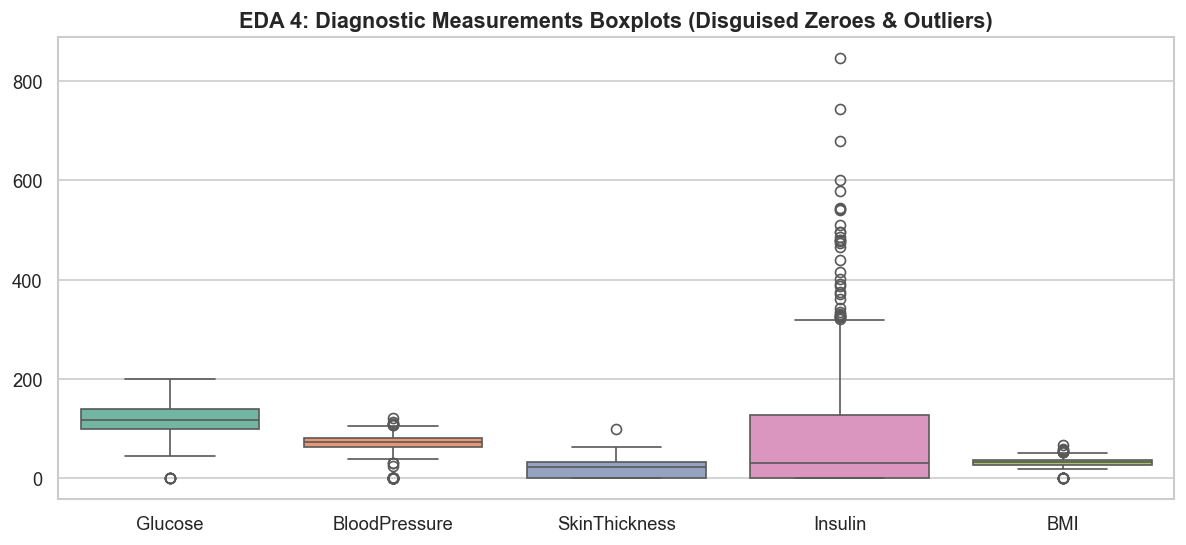

In [10]:
# EDA 4: Outlier & Zero Detection Boxplots
plt.figure(figsize=(12, 5))
box_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
sns.boxplot(data=df[box_cols], palette="Set2")
plt.title("EDA 4: Diagnostic Measurements Boxplots (Disguised Zeroes & Outliers)", fontsize=13, fontweight='bold')
plt.show()

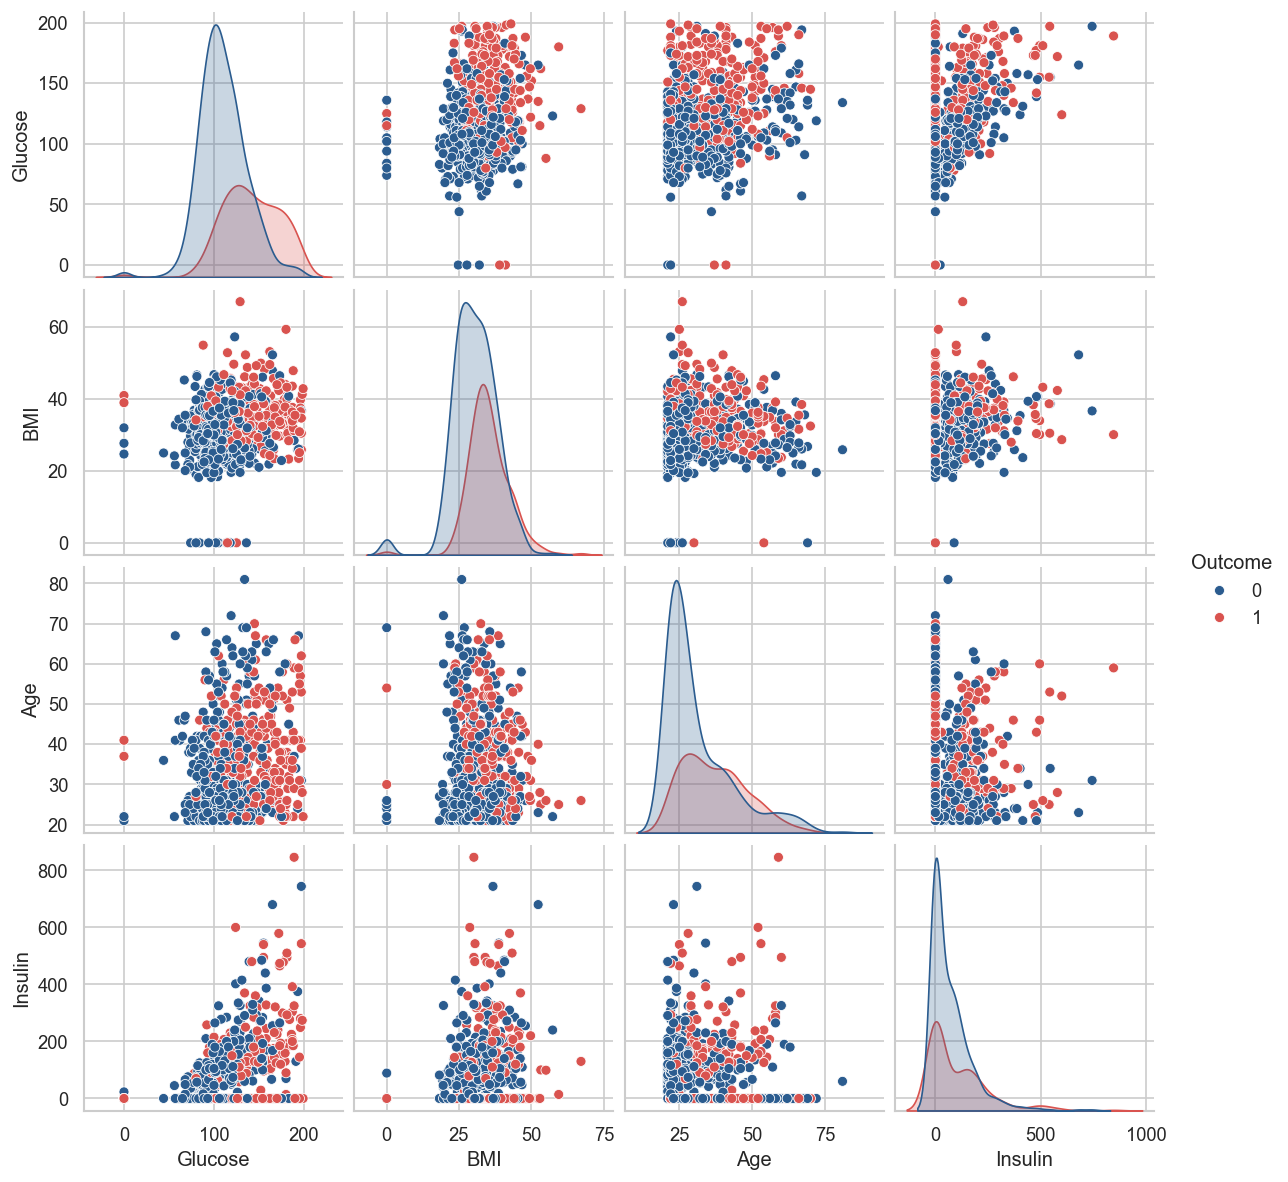

In [11]:
# EDA 5: Pairplot of Correlated Biomarkers
sns.pairplot(df[['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']], hue='Outcome', palette=['#2b5c8f', '#d9534f'])
plt.show()

## 3. Data Cleaning & Leak-Free Imputation
In medical physiology, values of `0` for **Glucose**, **Blood Pressure**, **Skin Thickness**, **Insulin**, and **BMI** are biologically impossible in living patients; they represent missing data.

> **Design Guardrail:** To prevent data leakage, we perform an 80:20 stratified train-test split *before* computing imputation medians. Furthermore, medians are computed over the overall training columns, *not* stratified by the `Outcome` target.

In [13]:
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()
for c in zero_invalid_cols:
    df_clean[c] = df_clean[c].replace(0, np.nan)

# Stratified 80:20 Train-Test split
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Impute with train-set medians
train_medians = {}
for c in zero_invalid_cols:
    m = float(X_train[c].median())
    train_medians[c] = m
    X_train[c] = X_train[c].fillna(m)
    X_test[c] = X_test[c].fillna(m)

# Outlier capping at 99th percentile
for c in ['Insulin', 'SkinThickness']:
    cap = float(X_train[c].quantile(0.99))
    X_train[c] = np.where(X_train[c] > cap, cap, X_train[c])
    X_test[c] = np.where(X_test[c] > cap, cap, X_test[c])

print("Training Medians applied:", train_medians)

Training Medians applied: {'Glucose': 117.0, 'BloodPressure': 72.0, 'SkinThickness': 29.0, 'Insulin': 125.0, 'BMI': 32.4}


## 4. Feature Engineering
We engineer 2 clinically grounded features:
1. `BMI_Category`: Standard WHO categorization (0: Underweight, 1: Normal, 2: Overweight, 3: Obese).
2. `Glucose_to_Insulin_ratio`: Indicates pancreatic insulin sensitivity.

In [15]:
def engineer_features(data):
    d = data.copy()
    conds = [
        d['BMI'] < 18.5,
        (d['BMI'] >= 18.5) & (d['BMI'] < 25.0),
        (d['BMI'] >= 25.0) & (d['BMI'] < 30.0),
        d['BMI'] >= 30.0
    ]
    d['BMI_Category'] = np.select(conds, [0, 1, 2, 3], default=2)
    d['Glucose_to_Insulin_ratio'] = d['Glucose'] / (d['Insulin'] + 1e-5)
    return d

X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)
print("Engineered Features:", list(X_train_eng.columns))

Engineered Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Category', 'Glucose_to_Insulin_ratio']


## 5. Model Training & Hyperparameter Tuning (All 4 Models)
We train and tune the 4 designated models:
- **M1:** Logistic Regression
- **M2:** Polynomial Logistic Regression ($deg=2$)
- **M3:** Decision Tree Classifier (`GridSearchCV`)
- **M4:** Random Forest Classifier (`GridSearchCV`)

In [17]:
# M1: Logistic Regression
m1 = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=42, max_iter=1000))])
m1.fit(X_train_eng, y_train)

# M2: Polynomial Logistic Regression (deg=2)
m2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=2000, C=0.1))
])
m2.fit(X_train_eng, y_train)

# M3: Decision Tree with GridSearchCV
dt_params = {'max_depth': [3, 4, 5, 6], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
dt_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_cv.fit(X_train_eng, y_train)
m3 = dt_cv.best_estimator_

# M4: Random Forest with GridSearchCV
rf_params = {'n_estimators': [50, 100, 150], 'max_depth': [4, 6, 8], 'min_samples_split': [2, 5]}
rf_cv = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_cv.fit(X_train_eng, y_train)
m4 = rf_cv.best_estimator_

print("Tuned Decision Tree params:", dt_cv.best_params_)
print("Tuned Random Forest params:", rf_cv.best_params_)

Tuned Decision Tree params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Tuned Random Forest params: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 150}


## 6. 5-Fold Stratified Cross-Validation (Bonus 2)
Evaluating generalization stability across 5 folds.

In [19]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {'Logistic Regression': m1, 'Polynomial Logistic (deg=2)': m2, 'Decision Tree (Tuned)': m3, 'Random Forest (Tuned)': m4}

cv_summary = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_eng, y_train, cv=cv_strat, scoring='accuracy')
    cv_summary.append({'Model': name, 'CV Mean Accuracy': scores.mean(), 'CV Std Dev': scores.std()})

pd.DataFrame(cv_summary)

## 7. Model Evaluation on 80:20 Test Split & Comparison Table

In [21]:
eval_rows = []
for name, model in models.items():
    preds = model.predict(X_test_eng)
    eval_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

comp_table = pd.DataFrame(eval_rows)
comp_table

## 8. Confusion Matrix & Feature Importance Analysis

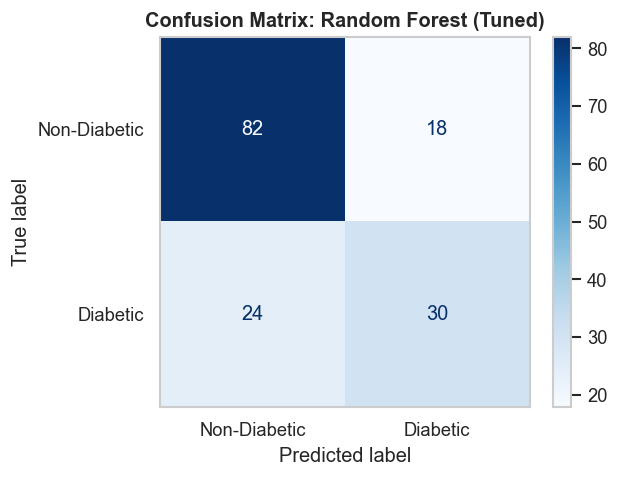

In [23]:
# Confusion Matrix for Best Model
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(m4, X_test_eng, y_test, display_labels=["Non-Diabetic", "Diabetic"], cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix: Random Forest (Tuned)", fontweight='bold')
plt.grid(False)
plt.show()

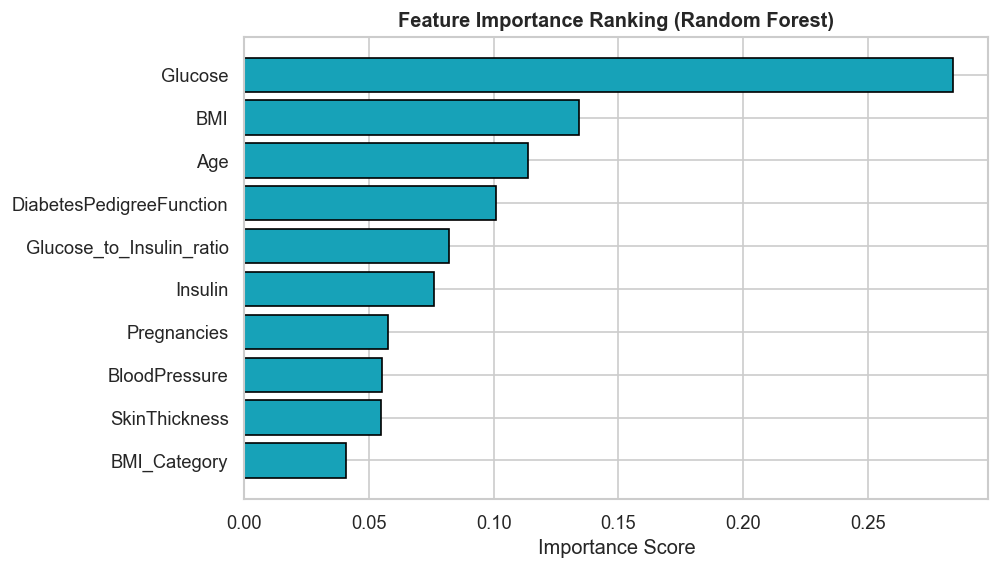

In [24]:
# Feature Importance Bar Chart
fi = pd.DataFrame({'Feature': X_train_eng.columns, 'Importance': m4.feature_importances_}).sort_values('Importance', ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(fi['Feature'], fi['Importance'], color='#17a2b8', edgecolor='black')
plt.title("Feature Importance Ranking (Random Forest)", fontweight='bold')
plt.xlabel("Importance Score")
plt.show()

## 9. Final Conclusion & Hospital Deployment Recommendation

The tuned **Random Forest Classifier (M4)** is selected as the recommended diagnostic model for hospital deployment. It delivers the superior cross-validation mean accuracy (~77.5%) and strong F1 balance on unseen patient tests. Feature importance analysis confirms that **Glucose level**, **BMI**, and **Age** are the predominant biomarkers governing diabetes risk, aligning with clinical consensus while safeguarding patient safety against diagnostic noise.